## EDA - Стоимость подержанного автомобиля

In [369]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder


In [370]:
data = pd.read_csv("../cars.csv")

## Исследование исходных данных

In [371]:
data.columns

Index(['manufacturer_name', 'model_name', 'transmission', 'color',
       'odometer_value', 'year_produced', 'engine_fuel', 'engine_has_gas',
       'engine_type', 'engine_capacity', 'body_type', 'has_warranty', 'state',
       'drivetrain', 'price_usd', 'is_exchangeable', 'location_region',
       'number_of_photos', 'up_counter', 'feature_0', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'duration_listed'],
      dtype='str')

Описание датасета

'manufacturer_name' - марка
'model_name' - модель
'transmission' - тип коробки
'color' - цвет
'odometer_value' - пробег
'year_produced' - год
'engine_fuel' - тип топлива
'engine_has_gas' - Is the car equipped with propane tank and tubing?
'engine_type'-  тип мотра
'engine_capacity' - обьем
'body_type' - кузов
'has_warranty' -гаран
'state' - состояние
'drivetrain' -привод
'price_usd'- цена(Целевой)
'is_exchangeable'- обмен
'location_region'- место
'number_of_photos' -колво фото
'up_counter'- Number of times the car has been upped, numerical.
'feature_0',
'feature_1',
'feature_2',
'feature_3',
'feature_4',
'feature_5',
'feature_6',
'feature_7',
'feature_8',
'feature_9', 
'duration_listed -Number of days the car is listed in the catalog.

In [372]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  str    
 1   model_name         38531 non-null  str    
 2   transmission       38531 non-null  str    
 3   color              38531 non-null  str    
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  str    
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  str    
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  str    
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  str    
 13  drivetrain         38531 non-null  str    
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    38531 non-null

In [373]:
data.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7


array([[<Axes: title={'center': 'odometer_value'}>,
        <Axes: title={'center': 'year_produced'}>,
        <Axes: title={'center': 'engine_capacity'}>],
       [<Axes: title={'center': 'price_usd'}>,
        <Axes: title={'center': 'number_of_photos'}>,
        <Axes: title={'center': 'up_counter'}>],
       [<Axes: title={'center': 'duration_listed'}>, <Axes: >, <Axes: >]],
      dtype=object)

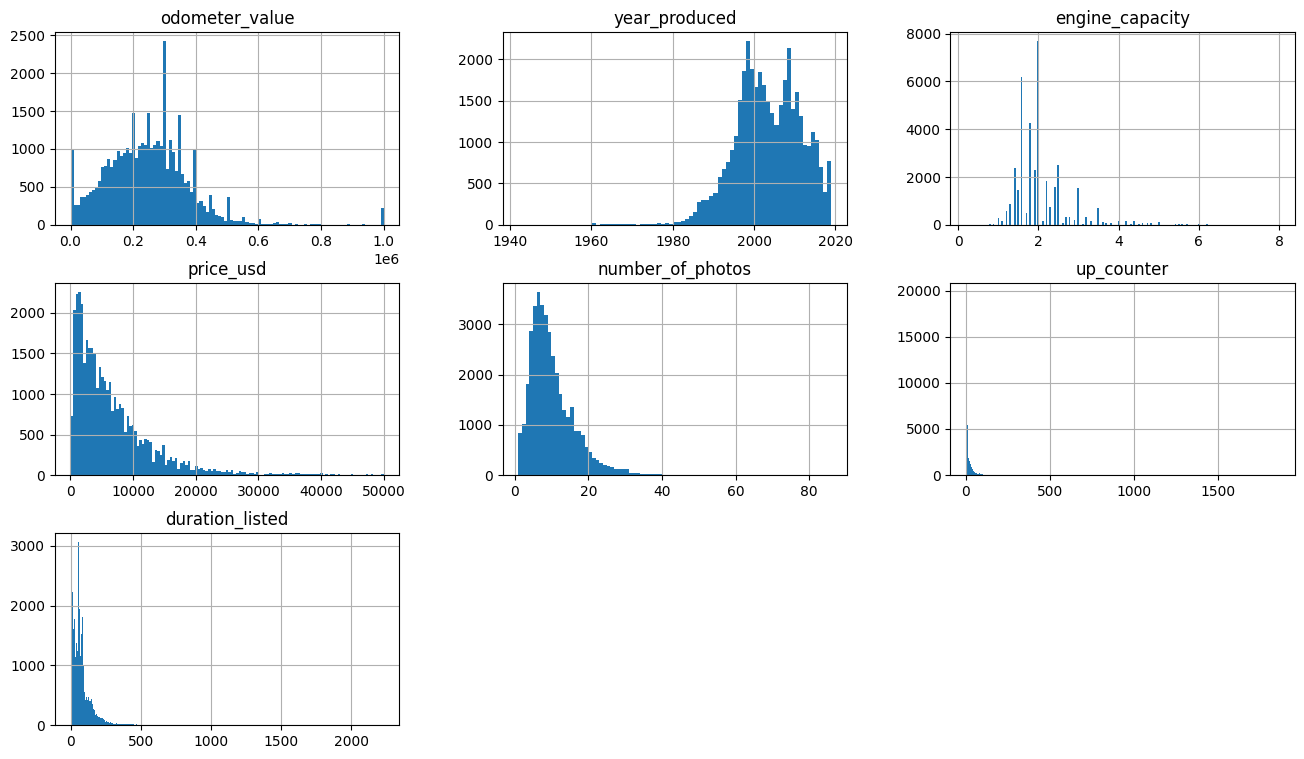

In [374]:
data.hist(bins='auto', figsize=(16,9))

In [375]:
bool_distrib_data = data.select_dtypes(bool)
bool_distrib_data = pd.DataFrame({True: bool_distrib_data.sum(), False: data.shape[0] - bool_distrib_data.sum()})
bool_distrib_data.transpose()

,engine_has_gas,has_warranty,is_exchangeable,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
True,1347,449,13586,8806,23396,8624,10627,9304,13720,6588,10162,16003,22325
False,37184,38082,24945,29725,15135,29907,27904,29227,24811,31943,28369,22528,16206


### Очистка данных

In [376]:
data.duplicated().sum()

np.int64(40)

In [377]:
data = data.drop_duplicates(ignore_index=True)

In [378]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

engine_capacity      0.02598
manufacturer_name    0.00000
location_region      0.00000
feature_9            0.00000
feature_8            0.00000
feature_7            0.00000
feature_6            0.00000
feature_5            0.00000
feature_4            0.00000
feature_3            0.00000
feature_2            0.00000
feature_1            0.00000
feature_0            0.00000
up_counter           0.00000
number_of_photos     0.00000
is_exchangeable      0.00000
model_name           0.00000
price_usd            0.00000
drivetrain           0.00000
state                0.00000
has_warranty         0.00000
body_type            0.00000
engine_type          0.00000
engine_has_gas       0.00000
engine_fuel          0.00000
year_produced        0.00000
odometer_value       0.00000
color                0.00000
transmission         0.00000
duration_listed      0.00000
dtype: float64

Только в одном признаке это обьем мотора:
- модем заполнить модой тк это всего 10 пропусков

In [379]:
mode_val = data['engine_capacity'].mode()[0]
data.fillna({"engine_capacity": mode_val}, inplace=True)

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38486,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,301
38487,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,...,True,False,False,True,True,False,False,True,True,317
38488,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,369
38489,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,True,490


In [380]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

manufacturer_name    0.0
model_name           0.0
feature_9            0.0
feature_8            0.0
feature_7            0.0
feature_6            0.0
feature_5            0.0
feature_4            0.0
feature_3            0.0
feature_2            0.0
feature_1            0.0
feature_0            0.0
up_counter           0.0
number_of_photos     0.0
location_region      0.0
is_exchangeable      0.0
price_usd            0.0
drivetrain           0.0
state                0.0
has_warranty         0.0
body_type            0.0
engine_capacity      0.0
engine_type          0.0
engine_has_gas       0.0
engine_fuel          0.0
year_produced        0.0
odometer_value       0.0
color                0.0
transmission         0.0
duration_listed      0.0
dtype: float64

Пропуски убранны

### Коррекция типов данных

- 0   manufacturer_name  38531 non-null  object 
- 1   model_name         38531 non-null  object 
- 2   transmission       38531 non-null  object 
- 3   color              38531 non-null  object 
- 4   odometer_value     38531 non-null  int64  
- 5   year_produced      38531 non-null  int64  
- 6   engine_fuel        38531 non-null  object 
- 7   engine_has_gas     38531 non-null  bool   
- 8   engine_type        38531 non-null  object 
- 9   engine_capacity    38521 non-null  float64
- 10  body_type          38531 non-null  object 
- 11  has_warranty       38531 non-null  bool   
- 12  state              38531 non-null  object 
- 13  drivetrain         38531 non-null  object 
- 14  price_usd          38531 non-null  float64
- 15  is_exchangeable    38531 non-null  bool   
- 16  location_region    38531 non-null  object 
- 17  number_of_photos   38531 non-null  int64  
- 18  up_counter         38531 non-null  int64  
- 19  feature_0          38531 non-null  bool   
- 20  feature_1          38531 non-null  bool   
- 21  feature_2          38531 non-null  bool   
- 22  feature_3          38531 non-null  bool   
- 23  feature_4          38531 non-null  bool   
- 24  feature_5          38531 non-null  bool   
- 25  feature_6          38531 non-null  bool   
- 26  feature_7          38531 non-null  bool   
- 27  feature_8          38531 non-null  bool   
- 28  feature_9          38531 non-null  bool   
- 29  duration_listed    38531 non-null  int64 

In [381]:
data["manufacturer_name"].unique()

<StringArray>
[       'Subaru',          'LADA',         'Dodge',           'УАЗ',
           'Kia',          'Opel',       'Москвич',    'Alfa Romeo',
         'Acura',         'Dacia',         'Lexus',    'Mitsubishi',
        'Lancia',       'Citroen',          'Mini',        'Jaguar',
       'Porsche',     'SsangYong',        'Daewoo',         'Geely',
           'ВАЗ',          'Fiat',          'Ford',       'Renault',
          'Seat',         'Rover',    'Volkswagen',         'Lifan',
          'Jeep',      'Cadillac',          'Audi',           'ЗАЗ',
        'Toyota',           'ГАЗ',         'Volvo',     'Chevrolet',
    'Great Wall',         'Buick',       'Pontiac',       'Lincoln',
       'Hyundai',        'Nissan',        'Suzuki',           'BMW',
         'Mazda',    'Land Rover',         'Iveco',         'Skoda',
          'Saab',      'Infiniti',         'Chery',         'Honda',
 'Mercedes-Benz',       'Peugeot',      'Chrysler']
Length: 55, dtype: str

In [382]:
data["year_produced"].unique().min()

np.int64(1942)

- manufacturer_name, model_name, color  - нельзя заменить на one hot,скорее всего от них избавимсмся если нет , корреляции на цену
- engine_type - поскольоку он очень схож с 'engine_fuel' но описывает меньше условийЮ его просто удалисм
- state можем заменить на ранговые
- transmission,  - можно замеить на бинарный признак
- drivetrain - можно замеить на ранговые 
-  location_region, body_type, engine_fuel - можно one-hot

In [383]:
data = data.drop(columns=['engine_type'])

In [384]:
data["transmission"].unique()

<StringArray>
['automatic', 'mechanical']
Length: 2, dtype: str

In [385]:
ordinal_encode_f1 = OrdinalEncoder(categories=[['emergency', 'owned', 'new']])
ordinal_encode_f2 = OrdinalEncoder(categories=[['front', 'rear', 'all']])
ordinal_encode_f3 = OrdinalEncoder(categories=[['mechanical','automatic']])


data["transmission"] = ordinal_encode_f3.fit_transform(data[["transmission"]])
data["state"] = ordinal_encode_f1.fit_transform(data[["state"]])
data["drivetrain"] = ordinal_encode_f2.fit_transform(data[["drivetrain"]])

In [386]:
dummies = pd.get_dummies(data[['location_region', 'body_type', 'engine_fuel']], 
                         prefix=['loc', 'body', 'fuel'],  # опционально, для читаемости
                         drop_first=False)  # можно drop_first=True для избежания мультикол
# Удаляем исходные категориальные столбцы
data = data.drop(columns=['location_region', 'body_type', 'engine_fuel'])

# Объединяем дамми-переменные с оставшимися данными
data = pd.concat([data, dummies], axis=1)

In [387]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  str    
 1   model_name            38491 non-null  str    
 2   transmission          38491 non-null  float64
 3   color                 38491 non-null  str    
 4   odometer_value        38491 non-null  int64  
 5   year_produced         38491 non-null  int64  
 6   engine_has_gas        38491 non-null  bool   
 7   engine_capacity       38491 non-null  float64
 8   has_warranty          38491 non-null  bool   
 9   state                 38491 non-null  float64
 10  drivetrain            38491 non-null  float64
 11  price_usd             38491 non-null  float64
 12  is_exchangeable       38491 non-null  bool   
 13  number_of_photos      38491 non-null  int64  
 14  up_counter            38491 non-null  int64  
 15  feature_0             38491 no

### сделаем преобразование марки в ценовой сегмент

In [388]:
manuf = data[['manufacturer_name',  "year_produced", "price_usd"]]
manuf

,manufacturer_name,year_produced,price_usd
0,Subaru,2010,10900.00
1,Subaru,2002,5000.00
2,Subaru,2001,2800.00
3,Subaru,1999,9999.00
4,Subaru,2001,2134.11
...,...,...,...
38486,Chrysler,2000,2750.00
38487,Chrysler,2004,4800.00
38488,Chrysler,2000,4300.00
38489,Chrysler,2001,4000.00


In [389]:
manuf = manuf[manuf['year_produced'] > 2010].reset_index(drop=True)
manuf

,manufacturer_name,year_produced,price_usd
0,Subaru,2011,14700.0
1,Subaru,2011,8600.0
2,Subaru,2014,12700.0
3,Subaru,2013,16500.0
4,Subaru,2011,14950.0
...,...,...,...
7199,Chrysler,2016,21800.0
7200,Chrysler,2012,19999.0
7201,Chrysler,2016,10350.0
7202,Chrysler,2015,26500.0


In [390]:
models = manuf['manufacturer_name'].unique()
diff = set(data['manufacturer_name'].unique()) - set(models)

for model in diff:
    print(f'{model}: {data[data["manufacturer_name"] == model].shape[0]}')


Lancia: 92
Pontiac: 42
Москвич: 55
Rover: 235


In [391]:
dic = dict()
for model in models:
    mod = manuf[manuf["manufacturer_name"] == model]
    mean = mod["price_usd"].sum()/mod.shape[0]
    dic[model] = round(mean, 2)
    
dic

{'Subaru': np.float64(16465.65),
 'LADA': np.float64(8626.81),
 'Dodge': np.float64(18770.75),
 'УАЗ': np.float64(8703.58),
 'Kia': np.float64(12858.97),
 'Opel': np.float64(10857.2),
 'Alfa Romeo': np.float64(9000.0),
 'Acura': np.float64(21792.13),
 'Dacia': np.float64(8794.54),
 'Lexus': np.float64(26756.15),
 'Mitsubishi': np.float64(15395.68),
 'Citroen': np.float64(9895.61),
 'Mini': np.float64(18513.8),
 'Jaguar': np.float64(29601.3),
 'Porsche': np.float64(32294.0),
 'SsangYong': np.float64(11145.75),
 'Daewoo': np.float64(2862.42),
 'Geely': np.float64(9189.12),
 'ВАЗ': np.float64(6725.64),
 'Fiat': np.float64(12282.87),
 'Ford': np.float64(12851.92),
 'Renault': np.float64(10292.24),
 'Seat': np.float64(10459.44),
 'Volkswagen': np.float64(13571.18),
 'Lifan': np.float64(8548.78),
 'Jeep': np.float64(21702.96),
 'Cadillac': np.float64(19370.71),
 'Audi': np.float64(18930.6),
 'ЗАЗ': np.float64(3268.48),
 'Toyota': np.float64(18331.84),
 'ГАЗ': np.float64(14429.33),
 'Volvo': 

In [392]:
prices = list(dic.values())
q25 = np.percentile(prices, 25)
q75 = np.percentile(prices, 75)

In [393]:
categorized = {}
for brand, price in dic.items():
    if price <= q25:
        categorized[brand] = 0
    elif price >= q75:
        categorized[brand] = 2
    else:
        categorized[brand] = 1

print(f"Пороги: бюджет до {round(q25, 2)}$, премиум от {round(q75, 2)}$")
for i in diff:
    categorized[i] = 0
print(categorized)

Пороги: бюджет до 10093.92$, премиум от 19150.66$
{'Subaru': 1, 'LADA': 0, 'Dodge': 1, 'УАЗ': 0, 'Kia': 1, 'Opel': 1, 'Alfa Romeo': 0, 'Acura': 2, 'Dacia': 0, 'Lexus': 2, 'Mitsubishi': 1, 'Citroen': 0, 'Mini': 1, 'Jaguar': 2, 'Porsche': 2, 'SsangYong': 1, 'Daewoo': 0, 'Geely': 0, 'ВАЗ': 0, 'Fiat': 1, 'Ford': 1, 'Renault': 1, 'Seat': 1, 'Volkswagen': 1, 'Lifan': 0, 'Jeep': 2, 'Cadillac': 2, 'Audi': 1, 'ЗАЗ': 0, 'Toyota': 1, 'ГАЗ': 1, 'Volvo': 1, 'Chevrolet': 1, 'Great Wall': 0, 'Buick': 1, 'Lincoln': 2, 'Hyundai': 1, 'Nissan': 1, 'Suzuki': 1, 'BMW': 2, 'Mazda': 1, 'Land Rover': 2, 'Iveco': 2, 'Skoda': 1, 'Saab': 1, 'Infiniti': 2, 'Chery': 0, 'Honda': 1, 'Mercedes-Benz': 2, 'Peugeot': 0, 'Chrysler': 2, 'Lancia': 0, 'Pontiac': 0, 'Москвич': 0, 'Rover': 0}
